# Model 6: Multivariate Dense Model (Window=7, Horizon=1)
This notebook demonstrates a multivariate dense neural network for Bitcoin price prediction using a window of 7 days to predict the next day.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
# Load Bitcoin historical data
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv

df = pd.read_csv('BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv', parse_dates=['Date'], index_col=['Date'])
bitcoin_prices = pd.DataFrame(df['Closing Price (USD)']).rename(columns={'Closing Price (USD)': 'Price'})
prices = bitcoin_prices['Price'].to_numpy()

--2025-10-22 01:09:59--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 178509 (174K) [text/plain]
Saving to: ‘BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv’

BTC_USD_2013-10-01_ 100%[===================>] 174.33K  --.-KB/s    in 0.03s   

2025-10-22 01:10:00 (6.56 MB/s) - ‘BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv’ saved [178509/178509]



In [3]:
# Add a second feature: daily returns
bitcoin_prices['Return'] = bitcoin_prices['Price'].pct_change().fillna(0)
multivariate_data = bitcoin_prices[['Price', 'Return']].to_numpy()

In [4]:
# Utility function for plotting
def plot_time_series(timesteps, values, format='.', start=0, end=None, label=None):
    plt.plot(timesteps[start:end], values[start:end], format, label=label)
    plt.xlabel('Time')
    plt.ylabel('BTC Price')
    if label:
        plt.legend(fontsize=14)
    plt.grid(True)

In [5]:
# Windowing functions for multivariate
def get_labelled_windows_mv(x, window_size=7, horizon=1):
    windows = []
    labels = []
    for i in range(len(x) - window_size - horizon + 1):
        window = x[i:i+window_size]
        label = x[i+window_size:i+window_size+horizon, 0]  # predict price only
        windows.append(window)
        labels.append(label)
    return np.array(windows), np.array(labels)
def make_train_test_splits(windows, labels, test_split=0.2):
    split_size = int(len(windows) * (1-test_split))
    train_windows = windows[:split_size]
    train_labels = labels[:split_size]
    test_windows = windows[split_size:]
    test_labels = labels[split_size:]
    return train_windows, test_windows, train_labels, test_labels

In [6]:
# Prepare windowed data
HORIZON = 1
WINDOW_SIZE = 7
full_windows, full_labels = get_labelled_windows_mv(multivariate_data, window_size=WINDOW_SIZE, horizon=HORIZON)
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)

## Build and Train Multivariate Dense Model

In [7]:
from tensorflow.keras import layers
tf.random.set_seed(42)
inputs = layers.Input(shape=(WINDOW_SIZE, 2))
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(HORIZON)(x)
model_6 = tf.keras.Model(inputs=inputs, outputs=output, name='model_6_multivariate_dense')
model_6.compile(loss='mae', optimizer=tf.keras.optimizers.Adam())
model_6.fit(train_windows, train_labels, epochs=100, verbose=0, batch_size=128, validation_data=(test_windows, test_labels))

## Evaluate Model

In [8]:
model_6.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 284.1881 


568.7185668945312

In [9]:
# Make predictions
def make_preds(model, input_data):
    forecast = model.predict(input_data)
    return tf.squeeze(forecast)
model_6_preds = make_preds(model_6, test_windows)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [10]:
# Evaluation metrics
def mean_absolute_scaled_error(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1]))
    return mae / mae_naive_no_season
def evaluate_preds(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)

    mae_metric  = tf.keras.metrics.MeanAbsoluteError()
    mse_metric  = tf.keras.metrics.MeanSquaredError()
    mape_metric = tf.keras.metrics.MeanAbsolutePercentageError()

    mae_metric.update_state(y_true, y_pred)
    mse_metric.update_state(y_true, y_pred)
    mape_metric.update_state(y_true, y_pred)

    rmse = tf.sqrt(mse_metric.result())
    mase = mean_absolute_scaled_error(y_true, y_pred)

    return {
        "mae": mae_metric.result().numpy(),
        "mse": mse_metric.result().numpy(),
        "rmse": rmse.numpy(),
        "mape": mape_metric.result().numpy(),
        "mase": mase.numpy()
    }

In [11]:
model_6_results = evaluate_preds(y_true=tf.squeeze(test_labels), y_pred=model_6_preds)
print(model_6_results)

{'mae': np.float32(568.7186), 'mse': np.float32(1169555.4), 'rmse': np.float32(1081.4598), 'mape': np.float32(2.538001), 'mase': np.float32(0.99908113)}


## Visualize Predictions

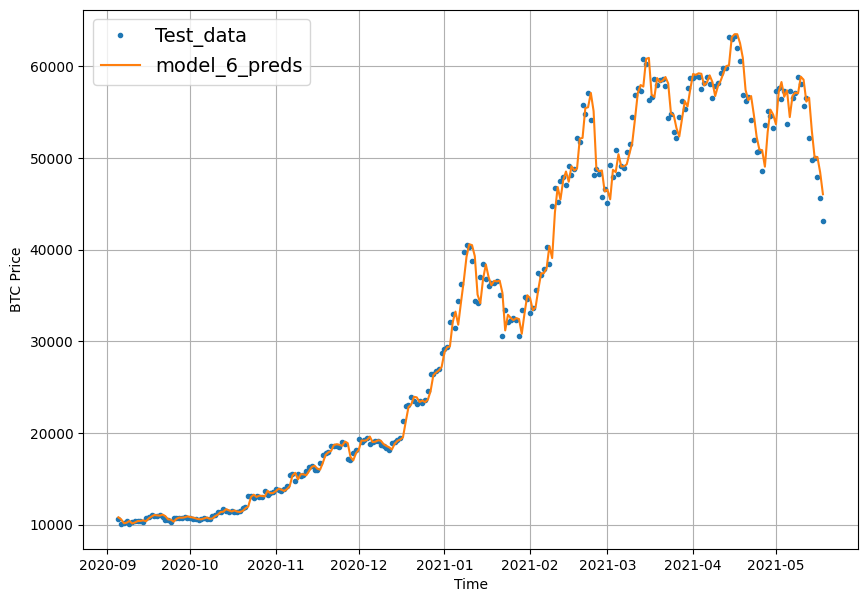

In [12]:
offset = 300
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=bitcoin_prices.index[-len(test_windows):], values=test_labels[:, 0], start=offset, label='Test_data')
plot_time_series(timesteps=bitcoin_prices.index[-len(test_windows):], values=model_6_preds, start=offset, format='-', label='model_6_preds')